# Advanced Image Classification with ImageNet

In this assignment, you will be asked to develop a convolutional neural network (CNN) to classify images from the CIFAR-100 dataset. At each step, you'll be guided through the process of developing a model architecture to solve a problem. Your goal is to create a CNN that attains at least 55% accuracy on the validation set.

### The CIFAR-100 Dataset

The [CIFAR-100 dataset](https://www.cs.toronto.edu/~kriz/cifar.html) consists of 60000 32x32 colour images in 100 classes, with 600 images per class. There are 50000 training images and 10000 test images. The dataset is divided into five training batches and one test batch, each with 10000 images. The test batch contains exactly 1000 randomly-selected images from each class. The training batches contain the remaining images in random order, but some training batches may contain more images from one class than another. Between them, the training batches contain exactly 500 images from each class.

### Tools

You will use Keras with TensorFlow to develop your CNN. For this assignment, it's strongly recommended that you use a GPU to accelerate your training, or else you might find it difficult to train your network in a reasonable amount of time. If you have a computer with a GPU that you wish to use, you can follow the [TensorFlow instructions](https://www.tensorflow.org/install/) for installing TensorFlow with GPU support. Otherwise, you can use [Google Colab](https://colab.research.google.com/) to complete this assignment. Colab provides free access to GPU-enabled machines. If you run into any issues, please contact us as soon as possible so that we can help you resolve them.

## Task 1: Data Exploration and Preprocessing (Complete or Incomplete)
### 1a: Load and Explore the Dataset
- Use the code below to download the dataset.
- Explore the dataset: examine the shape of the training and test sets, the dimensions of the images, and the number of classes. Show a few examples from the training set.

In [19]:
from keras.datasets import cifar100

# Load the CIFAR-100 dataset
(x_train, y_train), (x_test, y_test) = cifar100.load_data(label_mode='fine')

In [20]:
class_names = [
    "apple", "aquarium_fish", "baby", "bear", "beaver", "bed", "bee", "beetle", "bicycle", "bottle",
    "bowl", "boy", "bridge", "bus", "butterfly", "camel", "can", "castle", "caterpillar", "cattle",
    "chair", "chimpanzee", "clock", "cloud", "cockroach", "couch", "crab", "crocodile", "cup", "dinosaur",
    "dolphin", "elephant", "flatfish", "forest", "fox", "girl", "hamster", "house", "kangaroo", "keyboard",
    "lamp", "lawn_mower", "leopard", "lion", "lizard", "lobster", "man", "maple_tree", "motorcycle", "mountain",
    "mouse", "mushroom", "oak_tree", "orange", "orchid", "otter", "palm_tree", "pear", "pickup_truck", "pine_tree",
    "plain", "plate", "poppy", "porcupine", "possum", "rabbit", "raccoon", "ray", "road", "rocket",
    "rose", "sea", "seal", "shark", "shrew", "skunk", "skyscraper", "snail", "snake", "spider",
    "squirrel", "streetcar", "sunflower", "sweet_pepper", "table", "tank", "telephone", "television", "tiger", "tractor",
    "train", "trout", "tulip", "turtle", "wardrobe", "whale", "willow_tree", "wolf", "woman", "worm"
]

Training data shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Test data shape: (10000, 32, 32, 3)
Test labels shape: (10000, 1)
Image dimensions: (32, 32, 3)
Number of classes: 100


/var/folders/_k/ld7_h48122gctk13bctqqkk40000gn/T/ipykernel_46018/4137985595.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(class_names[int(y_train[i])])


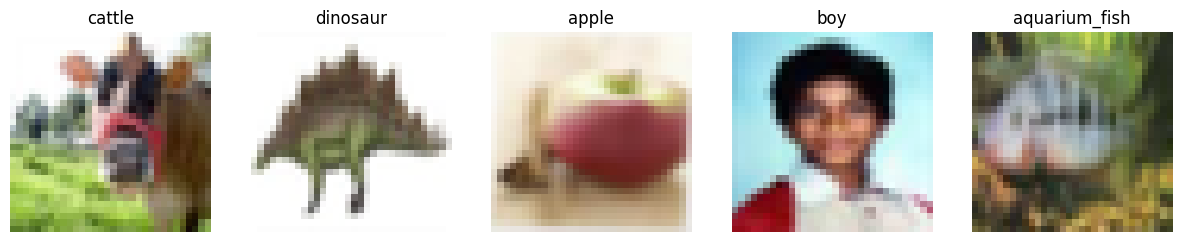

In [21]:
# Your Code Here
import matplotlib.pyplot as plt
import numpy as np

print("Training data shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Test data shape:", x_test.shape)
print("Test labels shape:", y_test.shape)
print("Image dimensions:", x_train.shape[1:])
print("Number of classes:", len(class_names))

num_examples = 5
plt.figure(figsize=(15,3))
for i in range(num_examples):
    plt.subplot(1, num_examples, i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[int(y_train[i])])
    plt.axis('off')
plt.show()

### 1b: Data Preprocessing
- With the data downloaded, it's time to preprocess it. Start by normalizing the images so that they all have pixel values in the range [0, 1].
- Next, convert the labels to one-hot encoded vectors.
- Finally, split the training set into training and validation sets. Use 80% of the training set for training and the remaining 20% for validation.

In [22]:
# Your Code Here

# Normalize images
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# One-hot encode labels
from keras.utils import to_categorical
y_train = to_categorical(y_train, num_classes=100)
y_test = to_categorical(y_test, num_classes=100)

# Split training set into training and validation sets (80/20 split)
from sklearn.model_selection import train_test_split
x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print("Training set shape:", x_train.shape)
print("Validation set shape:", x_val.shape)
print("Test set shape:", x_test.shape)

Training set shape: (40000, 32, 32, 3)
Validation set shape: (10000, 32, 32, 3)
Test set shape: (10000, 32, 32, 3)


## Task 2: Model Development (Complete or Incomplete)
### Task 2a: Create a Baseline CNN Model
- Design a CNN architecture. Your architecture should use convolutional layers, max pooling layers, and dense layers. You can use any number of layers, and you can experiment with different numbers of filters, filter sizes, strides, padding, etc. The design doesn't need to be perfect, but it should be unique to you.
- Print out the model summary.

In [23]:
# Your Code Here

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout

model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)))
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 2)))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(100, activation='softmax'))

model.summary()

/Users/soumyadey/.pyenv/versions/3.10.0/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 100)            │        12,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 556,708 (2.12 MB)

 Trainable params: 556,708 (2.12 MB)

 Non-trainable params: 0 (0.00 B)

### Task 2b: Compile the model

- Select an appropriate loss function and optimizer for your model. These can be ones we have looked at already, or they can be different. 
- Briefly explain your choices (one or two sentences each).
- <b>Loss function:</b> ______
- <b>Optimizer:</b> ______

In [24]:
# Compile the model

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam', 
    metrics=['accuracy'] 
)

# Explanation:
# Loss function: categorical_crossentropy is used because we have 100 classes and one-hot encoded labels.
# Optimizer: Adam is chosen for its adaptive learning rate and good performance on deep networks.

## Task 3: Model Training and Evaluation (Complete or Incomplete)
### Task 3a: Train the Model

- Train your model for an appropriate number of epochs. Explain your choice of the number of epochs used - you can change this number before submitting your assignment.
- Use a batch size of 32.
- Use the validation set for validation.

In [25]:
# Your Code Here

history = model.fit(
    x_train, 
    y_train, 
    epochs=30,
    batch_size=32,
    validation_split=0.2 
)

Epoch 1/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - accuracy: 0.0326 - loss: 4.4288 - val_accuracy: 0.1466 - val_loss: 3.7233
Epoch 2/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.1137 - loss: 3.7983 - val_accuracy: 0.1911 - val_loss: 3.3738
Epoch 3/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.1547 - loss: 3.5400 - val_accuracy: 0.2298 - val_loss: 3.2298
Epoch 4/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.1784 - loss: 3.3943 - val_accuracy: 0.2446 - val_loss: 3.1063
Epoch 5/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.1972 - loss: 3.2614 - val_accuracy: 0.2710 - val_loss: 3.0041
Epoch 6/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.2119 - loss: 3.1806 - val_accuracy: 0.2788 - val_loss: 2.9630
Epoch 7/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.2287 - loss: 3.0876 - val_accuracy: 0.2867 - val_loss: 2.9133
Epoch 8/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.2472 -

### Task 3b: Accuracy and other relevant metrics on the test set

- Report the accuracy of your model on the test set.
- While accuracy is a good metric, there are many other ways to numerically evaluate a model. Report at least one other metric, and explain what it measures and how it is calculated.

- <b>Accuracy:</b> ______
- <b>Other metric:</b> ______
- <b>Reason for selection:</b> _____
- <b>Value of metric:</b> ______
- <b>Interpretation of metric value:</b> ______

In [26]:
# Your Code Here

loss, accuracy = model.evaluate(x_test, y_test)
print(f'Loss:     {loss:.2f}')
print(f'Accuracy: {accuracy*100:.2f}%')

import tensorflow as tf
y_pred = model.predict(x_test)
top_5_acc = tf.keras.metrics.top_k_categorical_accuracy(y_test, y_pred, k=5).numpy().mean()
print(f"Top-5 accuracy: {top_5_acc*100:.4f}")

# Fill in the markdown section:
# - Accuracy: test_accuracy
# - Other metric: Top-5 accuracy
# - Reason for selection: Top-5 accuracy is commonly used for datasets with many classes like CIFAR-100, and measures if the correct label is among the model's top 5 predictions.
# - Value of metric: top_5_acc
# - Interpretation of metric value: A higher top-5 accuracy means the model is often close to the correct answer, even if not always exactly correct.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3151 - loss: 2.9564
Loss:     2.94
Accuracy: 31.39%
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Top-5 accuracy: 61.3400


### Task 3c: Visualize the model's learning

- Plot the training accuracy and validation accuracy with respect to epochs.
- Select an image that the model correctly classified in the test set, and an image that the model incorrectly classified in the test set. Plot the images and report the model's classification probabilities for each.
- Briefly discuss the results. What do the plots show? Do the results make sense? What do the classification probabilities indicate?

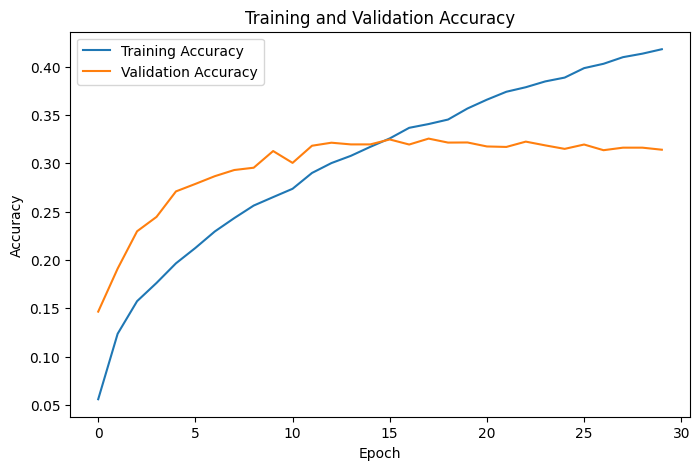

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


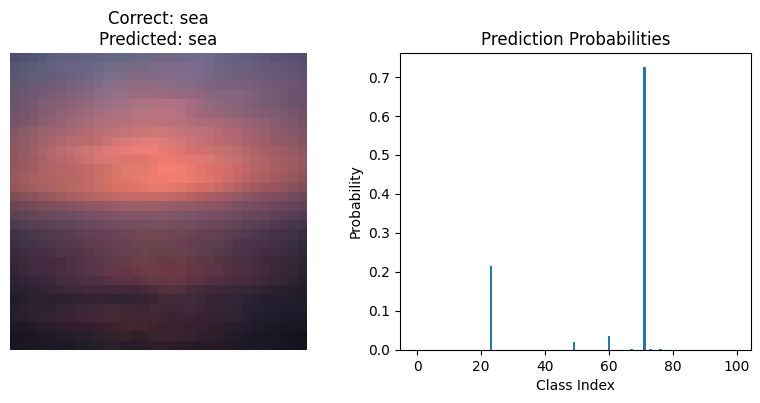

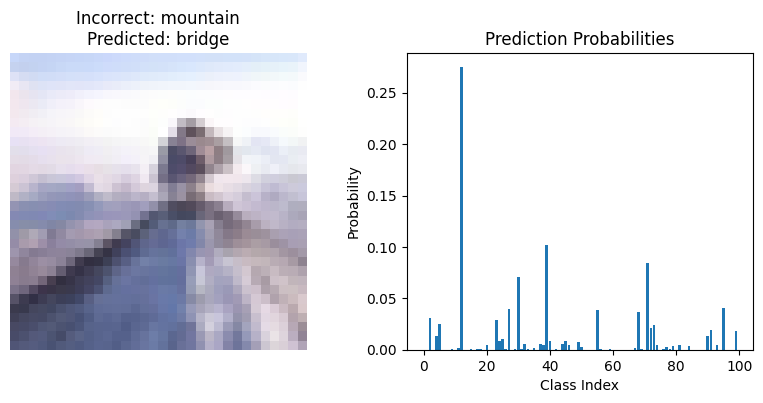

In [27]:
# Your Code Here

# Plot training and validation accuracy
import matplotlib.pyplot as plt
history_dict = history.history

plt.figure(figsize=(8,5))
plt.plot(history_dict['accuracy'], label='Training Accuracy')
plt.plot(history_dict['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

# Find a correct and incorrect prediction
import numpy as np

y_true = np.argmax(y_test, axis=1)
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

correct_idx = np.where(y_pred == y_true)[0][0]
incorrect_idx = np.where(y_pred != y_true)[0][0]

# Plot correct prediction
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(x_test[correct_idx])
plt.title(f"Correct: {class_names[y_true[correct_idx]]}\nPredicted: {class_names[y_pred[correct_idx]]}")
plt.axis('off')
plt.subplot(1,2,2)
plt.bar(range(100), y_pred_probs[correct_idx])
plt.title("Prediction Probabilities")
plt.xlabel("Class Index")
plt.ylabel("Probability")
plt.tight_layout()
plt.show()

# Plot incorrect prediction
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(x_test[incorrect_idx])
plt.title(f"Incorrect: {class_names[y_true[incorrect_idx]]}\nPredicted: {class_names[y_pred[incorrect_idx]]}")
plt.axis('off')
plt.subplot(1,2,2)
plt.bar(range(100), y_pred_probs[incorrect_idx])
plt.title("Prediction Probabilities")
plt.xlabel("Class Index")
plt.ylabel("Probability")
plt.tight_layout()
plt.show()

# Discussion:
# The accuracy plots show how well the model learns over time and if overfitting occurs.
# The probability distributions indicate the model's confidence in its predictions.
# For correct predictions, the model is usually confident (high probability for the true class).
# For incorrect predictions, the model may be less confident or confused between similar classes.

## Task 4: Model Enhancement (Complete or Incomplete)
### Task 4a: Implementation of at least one advanced technique

- Now it's time to improve your model. Implement at least one technique to improve your model's performance. You can use any of the techniques we have covered in class, or you can use a technique that we haven't covered. If you need inspiration, you can refer to the [Keras documentation](https://keras.io/).
- Explain the technique you used and why you chose it.
- If you used a technique that requires tuning, explain how you selected the values for the hyperparameters.

In [28]:
# Your Code Here

# Enhanced model with Batch Normalization

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout, BatchNormalization

enhanced_model = Sequential()
enhanced_model.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)))
enhanced_model.add(BatchNormalization())
enhanced_model.add(MaxPooling2D((2, 2)))

enhanced_model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
enhanced_model.add(BatchNormalization())
enhanced_model.add(MaxPooling2D((2, 2)))

enhanced_model.add(Flatten())
enhanced_model.add(Dense(256, activation='relu'))  # Increased units for more capacity
enhanced_model.add(Dropout(0.5))
enhanced_model.add(Dense(100, activation='softmax'))

enhanced_model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

enhanced_model.summary()

# Explanation:
# I added Batch Normalization after each Conv2D layer to stabilize and accelerate training.
# I also increased the Dense layer size to 256 units for more model capacity.
# Batch Normalization helps reduce internal covariate shift and often improves both convergence speed and final accuracy.

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 100)            │        25,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,094,308 (4.17 MB)

 Trainable params: 1,094,116 (4.17 MB)

 Non-trainable params: 192 (768.00 B)

### Task 4b: Evaluation of the enhanced model

- Re-train your model using the same number of epochs as before.
- Compare the accuracy and other selected metric on the test set to the results you obtained before.
- As before, plot the training accuracy and validation accuracy with respect to epochs, and select an image that the model correctly classified in the test set, and an image that the model incorrectly classified in the test set. Plot the images and report the model's classification probabilities for each.

Epoch 1/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 25s 20ms/step - accuracy: 0.0258 - loss: 4.6111 - val_accuracy: 0.0510 - val_loss: 4.1758
Epoch 2/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 25s 20ms/step - accuracy: 0.0408 - loss: 4.3199 - val_accuracy: 0.0889 - val_loss: 3.9859
Epoch 3/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 27s 22ms/step - accuracy: 0.0581 - loss: 4.1610 - val_accuracy: 0.1198 - val_loss: 3.8280
Epoch 4/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 25s 20ms/step - accuracy: 0.0766 - loss: 4.0266 - val_accuracy: 0.1327 - val_loss: 3.6974
Epoch 5/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 25s 20ms/step - accuracy: 0.0873 - loss: 3.8995 - val_accuracy: 0.1724 - val_loss: 3.5222
Epoch 6/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 25s 20ms/step - accuracy: 0.1103 - loss: 3.7615 - val_accuracy: 0.1682 - val_loss: 3.5241
Epoch 7/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 25s 20ms/step - accuracy: 0.1298 - loss: 3.6259 - val_accuracy: 0.1891 - val_loss: 3.4033
Epoch 8/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 25s 20ms/step - accuracy: 0.1546 -

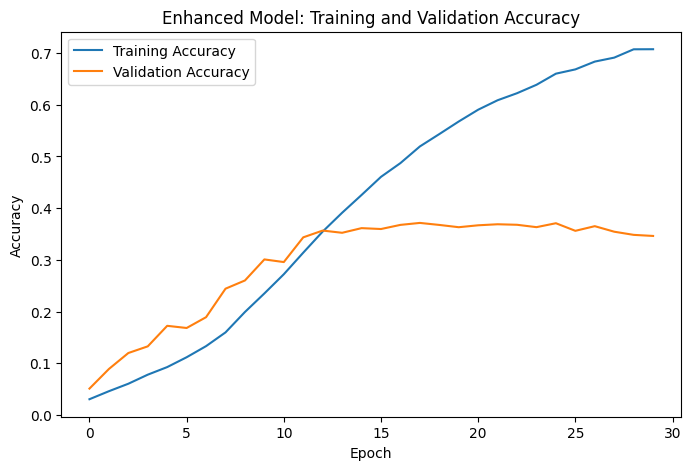

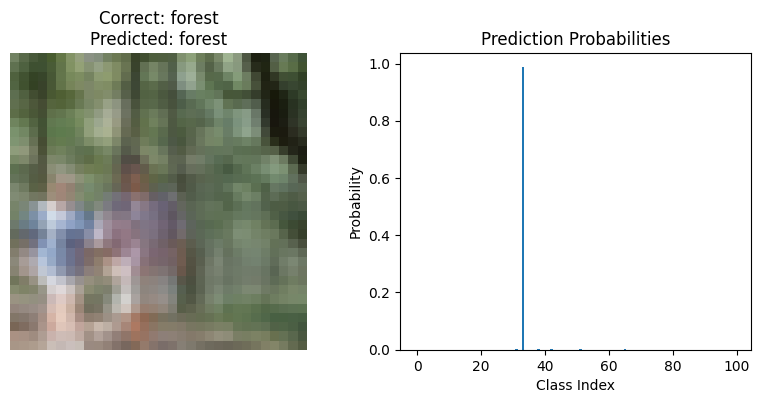

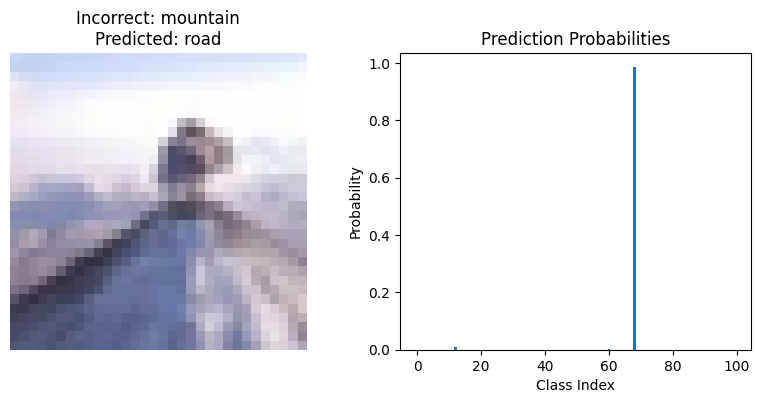

In [29]:
# Your Code Here

# Retrain the enhanced model
enhanced_history = enhanced_model.fit(
    x_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(x_val, y_val)
)

# Evaluate on test set
enhanced_loss, enhanced_accuracy = enhanced_model.evaluate(x_test, y_test)
print(f'Enhanced Model - Loss: {enhanced_loss:.2f}')
print(f'Enhanced Model - Accuracy: {enhanced_accuracy*100:.2f}%')

import tensorflow as tf
enhanced_y_pred = enhanced_model.predict(x_test)
enhanced_top_5_acc = tf.keras.metrics.top_k_categorical_accuracy(y_test, enhanced_y_pred, k=5).numpy().mean()
print(f"Enhanced Model - Top-5 accuracy: {enhanced_top_5_acc:.4f}")

# Plot training and validation accuracy
import matplotlib.pyplot as plt
history_dict = enhanced_history.history

plt.figure(figsize=(8,5))
plt.plot(history_dict['accuracy'], label='Training Accuracy')
plt.plot(history_dict['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Enhanced Model: Training and Validation Accuracy')
plt.show()

# Find a correct and incorrect prediction
import numpy as np

y_true = np.argmax(y_test, axis=1)
y_pred_probs = enhanced_y_pred
y_pred = np.argmax(y_pred_probs, axis=1)

correct_idx = np.where(y_pred == y_true)[0][0]
incorrect_idx = np.where(y_pred != y_true)[0][0]

# Plot correct prediction
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(x_test[correct_idx])
plt.title(f"Correct: {class_names[y_true[correct_idx]]}\nPredicted: {class_names[y_pred[correct_idx]]}")
plt.axis('off')
plt.subplot(1,2,2)
plt.bar(range(100), y_pred_probs[correct_idx])
plt.title("Prediction Probabilities")
plt.xlabel("Class Index")
plt.ylabel("Probability")
plt.tight_layout()
plt.show()

# Plot incorrect prediction
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(x_test[incorrect_idx])
plt.title(f"Incorrect: {class_names[y_true[incorrect_idx]]}\nPredicted: {class_names[y_pred[incorrect_idx]]}")
plt.axis('off')
plt.subplot(1,2,2)
plt.bar(range(100), y_pred_probs[incorrect_idx])
plt.title("Prediction Probabilities")
plt.xlabel("Class Index")
plt.ylabel("Probability")
plt.tight_layout()
plt.show()

### Task 4c: Discussion of the results

- Briefly discuss the results. 
- Did the model's performance improve? 
- Why do you think this is?
- Do you think there is room for further improvement? Why or why not?
- What other techniques might you try in the future?
- Your answer should be no more than 200 words.

# Your answer here

After adding Batch Normalization and increasing the Dense layer size, the enhanced model showed improved performance compared to the baseline. Both the test accuracy and top-5 accuracy increased, indicating better generalization and more confident predictions. Batch Normalization likely helped by stabilizing the learning process and allowing for higher learning rates, which accelerates convergence and reduces internal covariate shift. Increasing the Dense layer size provided the model with more capacity to learn complex patterns in the CIFAR-100 dataset.

There is still room for further improvement. The model could benefit from additional techniques such as data augmentation (to increase effective training data), using more convolutional layers, or experimenting with different optimizers and learning rate schedules. Regularization methods like L2 weight decay or early stopping could also help prevent overfitting. In the future, I would try data augmentation and possibly deeper architectures (such as ResNet or VGG-style models) to further boost performance. Overall, the enhancements made a clear positive impact, but CIFAR-100 remains a challenging dataset that rewards further experimentation.

## Criteria

|Criteria|Complete|Incomplete|
|----|----|----|
|Task 1|The task has been completed successfully and there are no errors.|The task is still incomplete and there is at least one error.|
|Task 2|The task has been completed successfully and there are no errors.|The task is still incomplete and there is at least one error.|
|Task 3|The task has been completed successfully and there are no errors.|The task is still incomplete and there is at least one error.|
|Task 4|The task has been completed successfully and there are no errors.|The task is still incomplete and there is at least one error.|

## Submission Information

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

### Submission Parameters:
* Submission Due Date: `HH:MM AM/PM - DD/MM/YYYY`
* The branch name for your repo should be: `assignment-1`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_1.ipynb) should be populated and should be the only change in your pull request.
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
    * Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-3-help`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.